In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, cross_val_score


import sys
from packaging import version
import sklearn

# Check Python version
if sys.version_info < (3, 7):
    raise ValueError(f"Python version must be 3.7 or higher. Found: {sys.version_info.major}.{sys.version_info.minor}")

# Check Scikit-learn version
if version.parse(sklearn.__version__) < version.parse("1.0.1"):
    raise ValueError(f"Scikit-learn version must be 1.0.1 or higher. Found: {sklearn.__version__}")

print("Environment checks passed: Python and Scikit-learn versions meet requirements.")


from pathlib import Path  # Importing the Path class from the pathlib module to handle file system paths
import pandas as pd  # Importing pandas as pd for data manipulation and analysis
import tarfile  # Importing the tarfile module to work with tar archive files
import urllib.request  # Importing urllib.request to handle URL operations

def load_bitcoin_data():
    bitcoin_path = Path("btcusd_1-min_data.csv")

    if not bitcoin_path.is_file():
       print("NOT FOUND")
        
    return pd.read_csv(Path("btcusd_1-min_data.csv"))

bitcoin = load_bitcoin_data()
print("Bitcoin data loaded successfully.")

Environment checks passed: Python and Scikit-learn versions meet requirements.
Bitcoin data loaded successfully.


In [2]:
# Visa de första raderna
print(bitcoin.head())

# Se datatyper och om det finns saknade värden (nulls)
print(bitcoin.info(show_counts=True))

# Se statistisk sammanfattning (min, max, standardavvikelse)
print(bitcoin.describe())

      Timestamp  Open  High   Low  Close  Volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0
3  1.325412e+09  4.58  4.58  4.58   4.58     0.0
4  1.325412e+09  4.58  4.58  4.58   4.58     0.0
<class 'pandas.DataFrame'>
RangeIndex: 7559696 entries, 0 to 7559695
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Timestamp  7559696 non-null  float64
 1   Open       7559696 non-null  float64
 2   High       7559696 non-null  float64
 3   Low        7559696 non-null  float64
 4   Close      7559696 non-null  float64
 5   Volume     7559696 non-null  float64
dtypes: float64(6)
memory usage: 346.1 MB
None
          Timestamp          Open          High           Low         Close  \
count  7.559696e+06  7.559696e+06  7.559696e+06  7.559696e+06  7.559696e+06   
mean   1.552209e+09  2.308835e+04  2.309645e+04  2.308009e+04  2

In [3]:
# 1. Konvertera Timestamp (Unix) till datetime och sätt som index
bitcoin['Datetime'] = pd.to_datetime(bitcoin['Timestamp'], unit='s')
bitcoin.set_index('Datetime', inplace=True)
bitcoin.drop(columns=['Timestamp'], inplace=True)

# 2. Skapa Target (nästa minuts stängningspris)
bitcoin['Target'] = bitcoin['Close'].shift(-1)

# 3. Skapa dina Features
bitcoin['Return_1m'] = bitcoin['Close'].pct_change()        # Avkastning senaste minuten
bitcoin['MA_5'] = bitcoin['Close'].rolling(window=5).mean()   # 5 minuters rörligt medelvärde
bitcoin['MA_30'] = bitcoin['Close'].rolling(window=30).mean() # 30 minuters rörligt medelvärde

# Ta bort rader med NaN (skapade av skiftningar och rörliga medelvärden)
bitcoin.dropna(inplace=True)

print("Features skapade. Ny form på data:", bitcoin.shape)

Features skapade. Ny form på data: (7559666, 9)


In [4]:
# Se till att indexet är datetime (det gjorde vi i tidigare steg)
# Vi skapar en ny dataframe för dagsdata
df_daily = pd.DataFrame()

df_daily['Open'] = bitcoin['Open'].resample('D').first()
df_daily['High'] = bitcoin['High'].resample('D').max()
df_daily['Low'] = bitcoin['Low'].resample('D').min()
df_daily['Close'] = bitcoin['Close'].resample('D').last()
df_daily['Volume'] = bitcoin['Volume'].resample('D').sum()

# Ta bort eventuella dagar helt utan data (t.ex. om det saknades historik)
df_daily.dropna(inplace=True)

#--------------
print(f"Datasetet har ändrats från 7,5 miljoner rader till {df_daily.shape[0]} dagar!")

Datasetet har ändrats från 7,5 miljoner rader till 5252 dagar!


In [5]:
# 1. Skapa morgondagens pris och Target (Upp = 1, Ner/Stilla = 0)
df_daily['Next_Close'] = df_daily['Close'].shift(-1)
df_daily['Target'] = (df_daily['Next_Close'] > df_daily['Close']).astype(int)

# 2. Skapa ett urval av de bästa och mest stabila indikatorerna
df_daily['Return_1d'] = df_daily['Close'].pct_change()
df_daily['MA_5'] = df_daily['Close'].rolling(window=5).mean()
df_daily['MA_20'] = df_daily['Close'].rolling(window=20).mean()
df_daily['High_Low_Spread'] = df_daily['High'] - df_daily['Low']
df_daily['Dist_to_MA_5'] = (df_daily['Close'] - df_daily['MA_5']) / df_daily['MA_5']

# 3. VIKTIGT: Rensa bort de nya NaN-värdena som skapades av rolling och shift
df_daily.dropna(inplace=True)

# 4. Separera i X (features) och y (target)
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Return_1d', 'MA_5', 'MA_20', 'High_Low_Spread', 'Dist_to_MA_5']
X = df_daily[feature_cols]
y = df_daily['Target']

print("---BASELINE ---")
print(f"Antal dagar kvar att träna på: {X.shape[0]}")
print("\nKlassfördelning (faktiska upp- och nergångar):")
print(y.value_counts())

---BASELINE ---
Antal dagar kvar att träna på: 5232

Klassfördelning (faktiska upp- och nergångar):
Target
1    2781
0    2451
Name: count, dtype: int64


Träningsdata storlek: 4185 dagar
Testdata storlek:     1047 dagar

Kör korsvalidering för Logistisk Regression...
Kör korsvalidering för Random Forest Classifier...

Logistic Regression CV Accuracy: 49.66% (Std: 0.0199)
Random Forest Classifier CV Accuracy: 51.17% (Std: 0.0148)
------------------------------------------------------------
Tränar Random Forest på träningsdatan...

⭐ Slutgiltig Accuracy på testdatan (Tröskel 0.44): 51.58% ⭐

--- DETALJERAD RAPPORT ---
                precision    recall  f1-score   support

Ner/Stilla (0)       0.50      0.65      0.57       512
       Upp (1)       0.54      0.39      0.45       535

      accuracy                           0.52      1047
     macro avg       0.52      0.52      0.51      1047
  weighted avg       0.52      0.52      0.51      1047



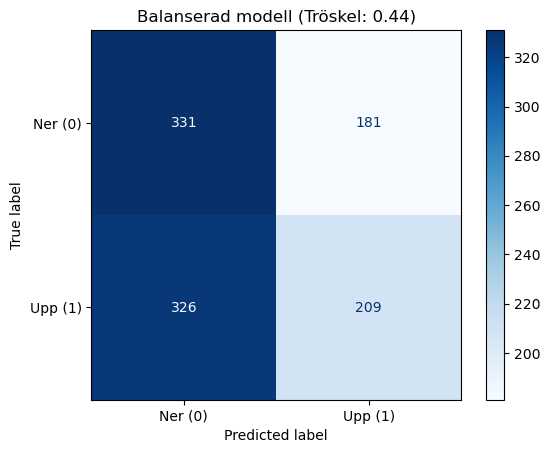

In [6]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# 1. KRONOLOGISK SPLIT (80% Train, 20% Test)
# ==========================================
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Träningsdata storlek: {X_train.shape[0]} dagar")
print(f"Testdata storlek:     {X_test.shape[0]} dagar\n")

# ==========================================
# 2. SKAPA MODELLER (Med balanserade vikter)
# ==========================================
log_reg = LogisticRegression(max_iter=1000)

forest_clf = RandomForestClassifier(
    n_estimators=10000,            
    max_depth=6,                  
    min_samples_leaf=2,           
    class_weight={0: 0.5, 1: 1}, # NYTT STRAFF: Att missa en uppgång (1) 
                                    # straffas nu 30% hårdare än att göra ett felköp.
    random_state=42, 
    n_jobs=-1
)

# ==========================================
# 3. BYGG PIPELINES (Skalning + Modell)
# ==========================================
pipe_log = Pipeline([('scaler', StandardScaler()), ('log_reg', log_reg)])
pipe_forest = Pipeline([('scaler', StandardScaler()), ('forest_clf', forest_clf)])

# ==========================================
# 4. KORSVALIDERING (Rullande tidsserie)
# ==========================================
tscv = TimeSeriesSplit(n_splits=5)

print("Kör korsvalidering för Logistisk Regression...")
log_scores = cross_val_score(pipe_log, X.values, y, cv=tscv, scoring="accuracy")

print("Kör korsvalidering för Random Forest Classifier...")
forest_scores = cross_val_score(pipe_forest, X.values, y, cv=tscv, scoring="accuracy")

print(f"\nLogistic Regression CV Accuracy: {log_scores.mean() * 100:.2f}% (Std: {log_scores.std():.4f})")
print(f"Random Forest Classifier CV Accuracy: {forest_scores.mean() * 100:.2f}% (Std: {forest_scores.std():.4f})")
print("-" * 60)

# ==========================================
# 5. SLUTGILTIG TRÄNING OCH PREDIKTION
# ==========================================
print("Tränar Random Forest på träningsdatan...")
pipe_forest.fit(X_train.values, y_train)

# Hämta exakta sannolikheter för "Upp" (klass 1) på testdatan
y_probs = pipe_forest.predict_proba(X_test.values)[:, 1]

# Applicera det modiga men straffade tröskelvärdet
custom_threshold = 0.44
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# ==========================================
# 6. UTVÄRDERING (Slutgiltigt testresultat)
# ==========================================
print(f"\n⭐ Slutgiltig Accuracy på testdatan (Tröskel {custom_threshold}): {accuracy_score(y_test, y_pred_custom) * 100:.2f}% ⭐\n")

print("--- DETALJERAD RAPPORT ---")
print(classification_report(y_test, y_pred_custom, target_names=['Ner/Stilla (0)', 'Upp (1)']))

# Rita upp Förvirringsmatrisen
cm = confusion_matrix(y_test, y_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ner (0)', 'Upp (1)'])
disp.plot(cmap='Blues')
plt.title(f'Balanserad modell (Tröskel: {custom_threshold})')
plt.show()

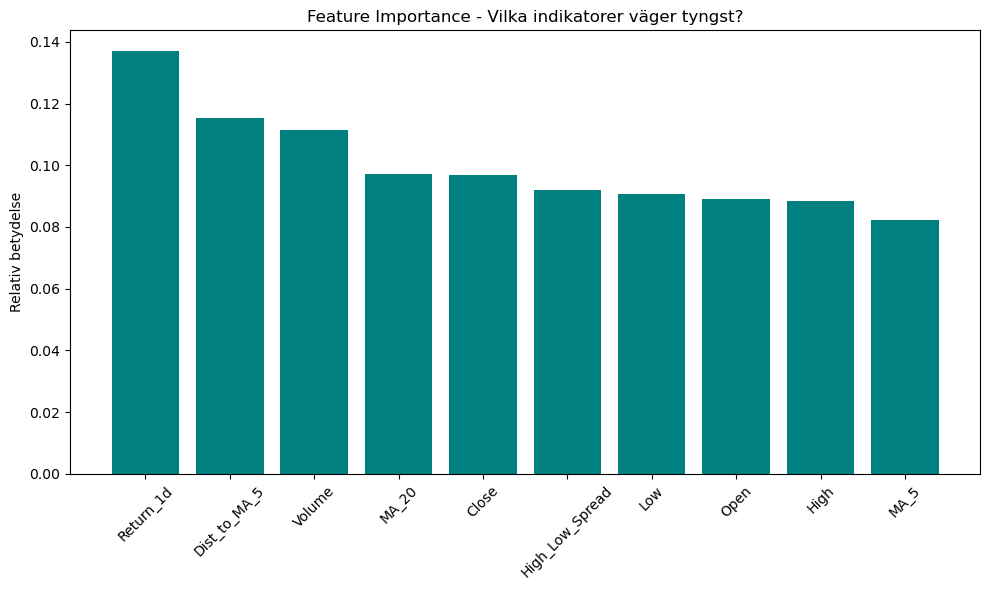

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Hämta importances från Random Forest-modellen inuti vår pipeline
importances = pipe_forest.named_steps['forest_clf'].feature_importances_

# Sortera dem i fallande ordning
indices = np.argsort(importances)[::-1]
sorted_features = [feature_cols[i] for i in indices]

plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), importances[indices], color='teal', align='center')
plt.xticks(range(X.shape[1]), sorted_features, rotation=45)
plt.title('Feature Importance - Vilka indikatorer väger tyngst?')
plt.ylabel('Relativ betydelse')
plt.tight_layout()
plt.show()

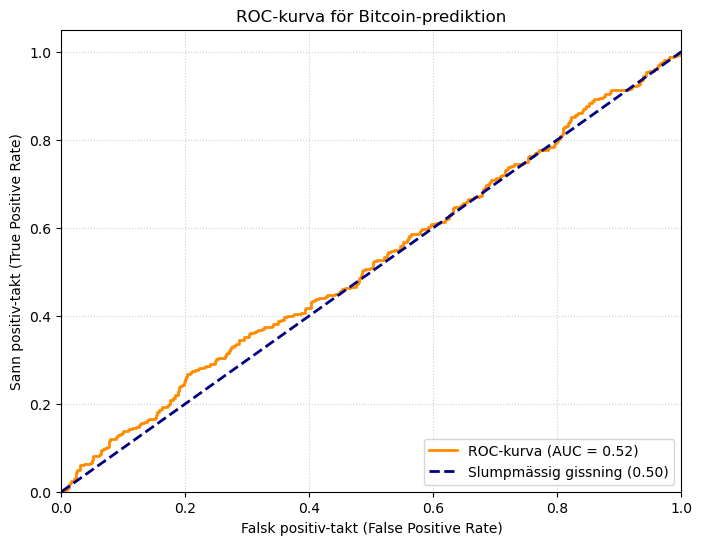

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# RÄTTAD RAD: Vi lägger till .values här så att StandardScaler slipper varna
y_probs = pipe_forest.predict_proba(X_test.values)[:, 1]

# Beräkna falsk positiv-takt och sann positiv-takt
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-kurva (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Slumpmässig gissning (0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Falsk positiv-takt (False Positive Rate)')
plt.ylabel('Sann positiv-takt (True Positive Rate)')
plt.title('ROC-kurva för Bitcoin-prediktion')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

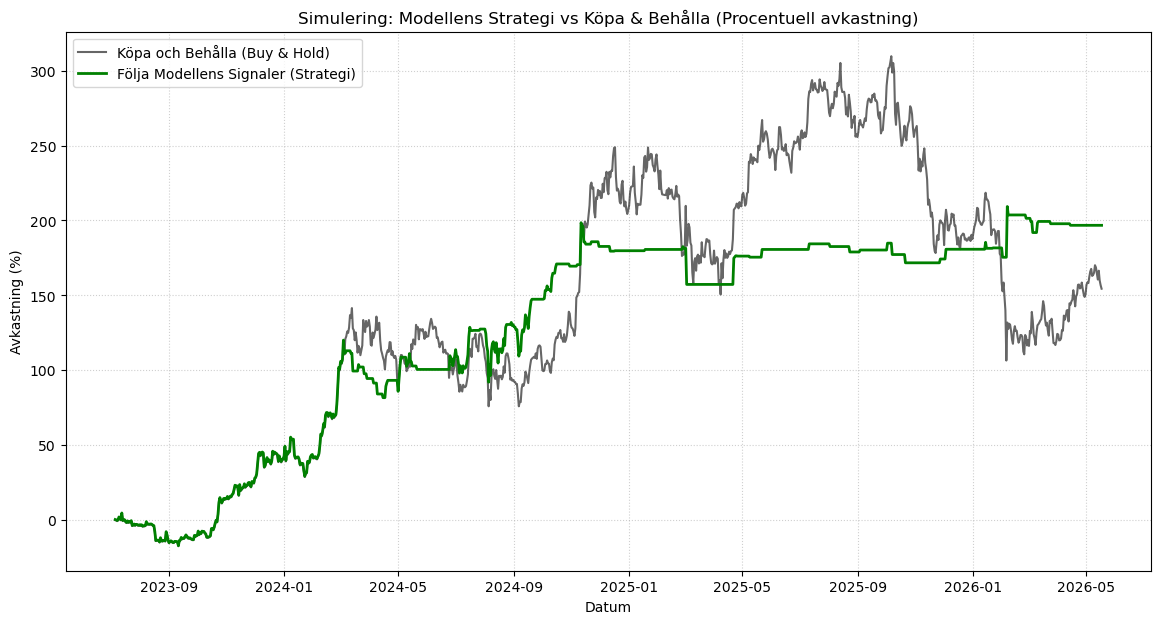

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Skapa en kopia av test-datan för att räkna ut avkastning
strategy_df = pd.DataFrame(index=y_test.index)
strategy_df['Market_Return'] = X_test['Return_1d']

# RÄTTAD RAD: Vi använder y_pred_custom från din nya balanserade modell!
strategy_df['Predicted_Signal'] = y_pred_custom

# 2. Om modellen gissar 1 får vi marknadens avkastning nästa dag. 
# Vi skiftar signalen med 1 eftersom vi agerar på signalen inför NÄSTA dag.
strategy_df['Strategy_Return'] = strategy_df['Market_Return'] * strategy_df['Predicted_Signal'].shift(1)

# Fyll i första raden som annars blir NaN
strategy_df.fillna(0, inplace=True)

# 3. Beräkna kumulativ avkastning (procentuell utveckling över tid)
cum_market = (1 + strategy_df['Market_Return']).cumprod() - 1
cum_strategy = (1 + strategy_df['Strategy_Return']).cumprod() - 1

# 4. Plotta resultatet
plt.figure(figsize=(14, 7))
plt.plot(cum_market.index, cum_market * 100, label='Köpa och Behålla (Buy & Hold)', color='black', alpha=0.6)
plt.plot(cum_strategy.index, cum_strategy * 100, label='Följa Modellens Signaler (Strategi)', color='green', linewidth=2)
plt.title('Simulering: Modellens Strategi vs Köpa & Behålla (Procentuell avkastning)')
plt.xlabel('Datum')
plt.ylabel('Avkastning (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [10]:
from sklearn.metrics import classification_report

# Skriv ut en detaljerad rapport för vår Random Forest
rapport = classification_report(y_test, y_pred, target_names=['Ner/Stilla (0)', 'Upp (1)'])

print("--- DETALJERAD ACCURACY-RAPPORT ---")
print(rapport)

NameError: name 'y_pred' is not defined

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# RÄTTAD RAD: Vi lägger till .values här så att StandardScaler slipper varna
y_probs = pipe_forest.predict_proba(X_test.values)[:, 1]

plt.figure(figsize=(10, 6))

# Plotta vad modellen gissade när det FAKTISKT gick upp (grönt)
sns.histplot(y_probs[y_test == 1], bins=30, color='green', alpha=0.5, label='Dagar som gick Upp', kde=True)

# Plotta vad modellen gissade när det FAKTISKT gick ner (rött)
sns.histplot(y_probs[y_test == 0], bins=30, color='red', alpha=0.5, label='Dagar som gick Ner', kde=True)

# RÄTTAD RAD: Vi ändrar linjen till 0.47 så den matchar ditt valda tröskelvärde!
custom_threshold = 0.47
plt.axvline(custom_threshold, color='black', linestyle='--', linewidth=2, label=f'{custom_threshold*100}% Tröskel (Ditt val)')
plt.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='50% Standardtröskel')

plt.title('Sannolikhetsfördelning - Hur säker är modellen på sina gissningar?')
plt.xlabel('Sannolikhet att priset går Upp (Enligt modellen)')
plt.ylabel('Antal dagar')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
import pandas as pd

# 1. Bygg om dagsdatan (utan att ta bort sista dagen)
df_latest = pd.DataFrame()
df_latest['Open'] = bitcoin['Open'].resample('D').first()
df_latest['High'] = bitcoin['High'].resample('D').max()
df_latest['Low'] = bitcoin['Low'].resample('D').min()
df_latest['Close'] = bitcoin['Close'].resample('D').last()
df_latest['Volume'] = bitcoin['Volume'].resample('D').sum()

# 2. Skapa dina features (EXAKT de 10 som modellen är tränad på nu)
df_latest['Return_1d'] = df_latest['Close'].pct_change()
df_latest['MA_5'] = df_latest['Close'].rolling(window=5).mean()
df_latest['MA_20'] = df_latest['Close'].rolling(window=20).mean()
df_latest['High_Low_Spread'] = df_latest['High'] - df_latest['Low']
df_latest['Dist_to_MA_5'] = (df_latest['Close'] - df_latest['MA_5']) / df_latest['MA_5']

# Se till att listan med features matchar perfekt
feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume', 
    'Return_1d', 'MA_5', 'MA_20', 
    'High_Low_Spread', 'Dist_to_MA_5'
]

# 3. Plocka ut den ALLRA SISTA dagen i historiken
last_day_data = df_latest[feature_cols].iloc[-1:]

# Skriv ut vilket datum modellen gissar utifrån
print(f"Modellen analyserar data från: {last_day_data.index[0].strftime('%Y-%m-%d')}")
print(f"Stängningspris den dagen: {last_day_data['Close'].values[0]:.2f} USD\n")

# 4. Hämta sannolikheterna från vår tränade PIPELINE (med .values för att slippa varningar)
probabilities = pipe_forest.predict_proba(last_day_data.values)
prob_up = probabilities[0][1] # Sannolikheten för att priset går UPP

# 5. Sätt ditt anpassade tröskelvärde från trading-strategin
custom_threshold = 0.47

# 6. Räkna ut prediktionen baserat på ditt tröskelvärde
if prob_up >= custom_threshold:
    final_prediction = 1
else:
    final_prediction = 0

# 7. Skriv ut det spännande resultatet!
print("🔮 --- STRATEGISK PREDIKTION FÖR NÄSTA DAG --- 🔮")
print(f"Modellens beräknade chans för uppgång: {prob_up * 100:.1f}%")
print(f"Din valda aktiveringsgräns (Threshold): {custom_threshold * 100:.1f}%\n")

if final_prediction == 1:
    print("UPP/KÖP  (Modellens säkerhet räcker för att köpa!)")
else:
    print("NER eller STILLA/SÄLJ (Modellen är för osäker, sitt i kontanter!)")